In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

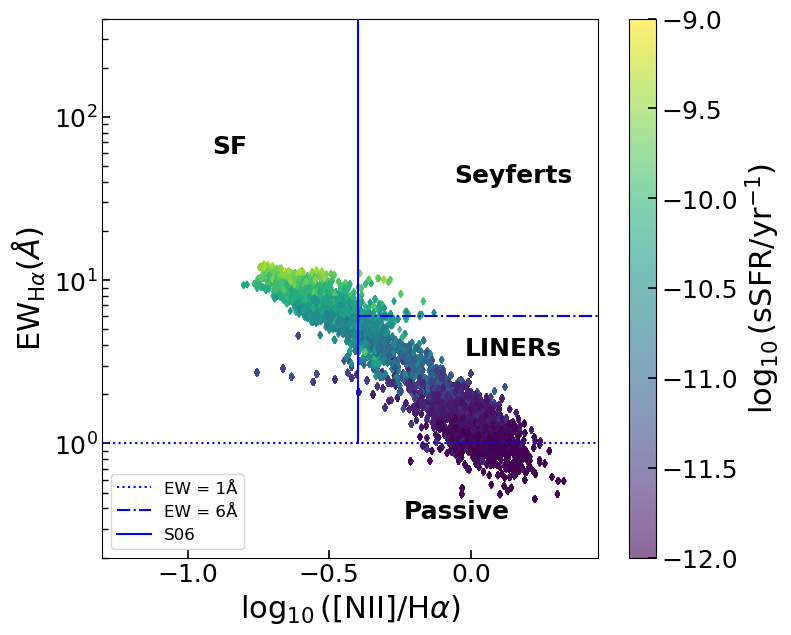

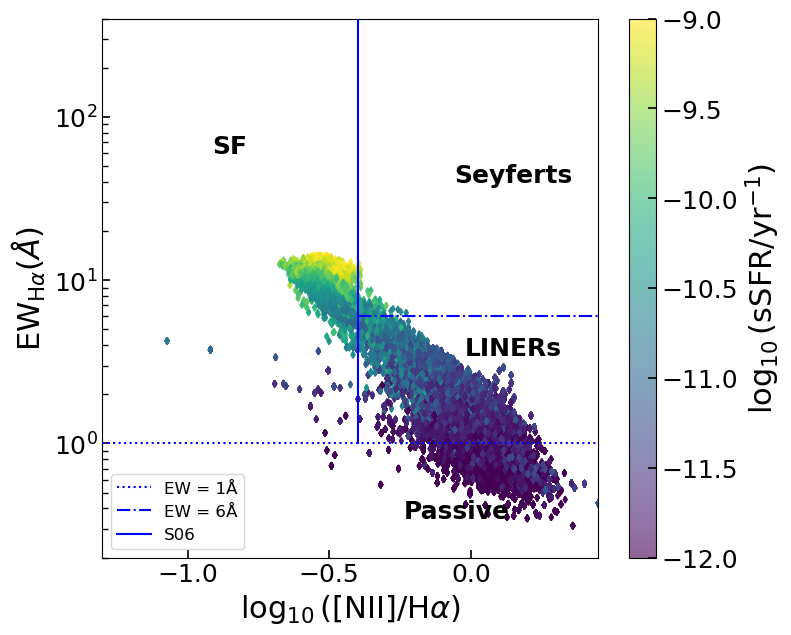

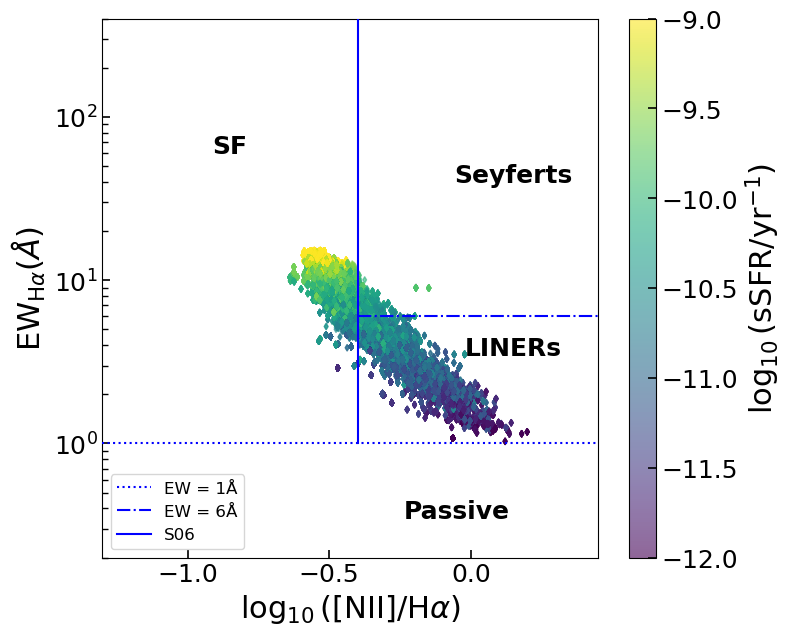

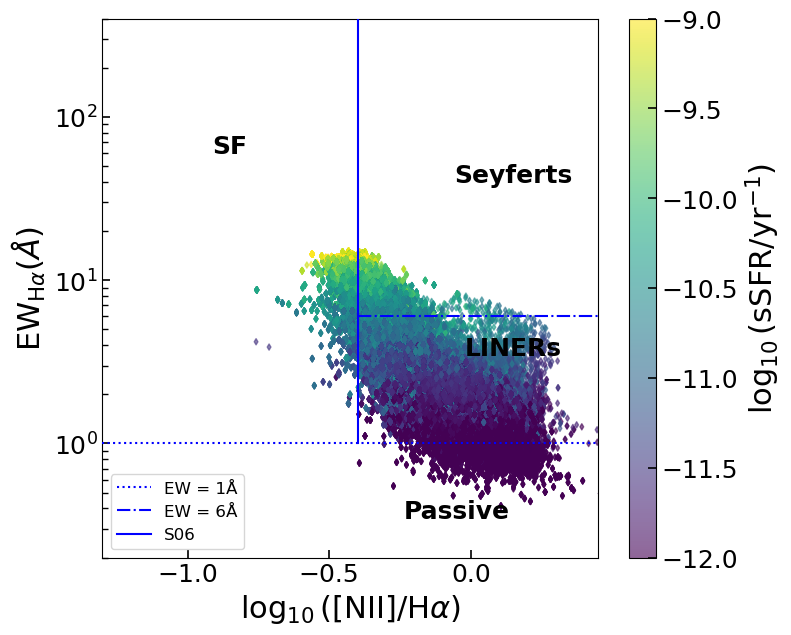

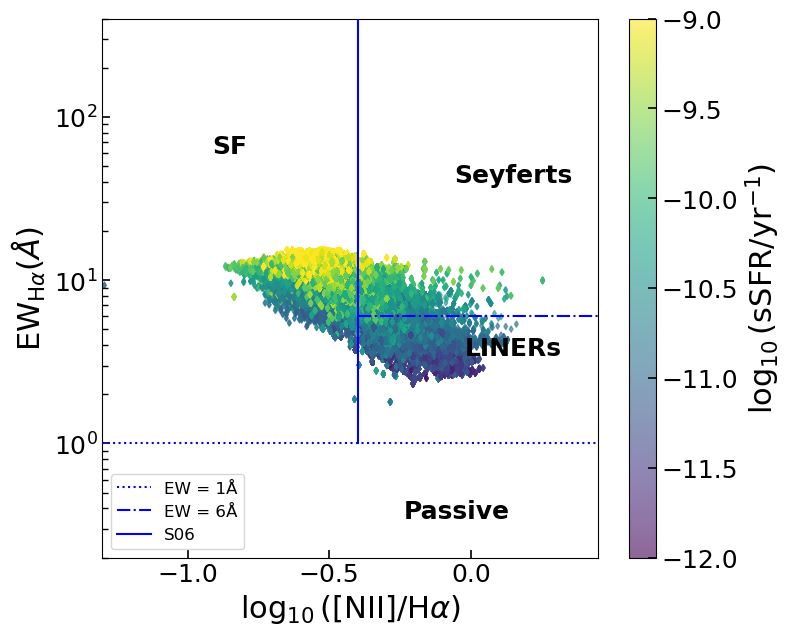

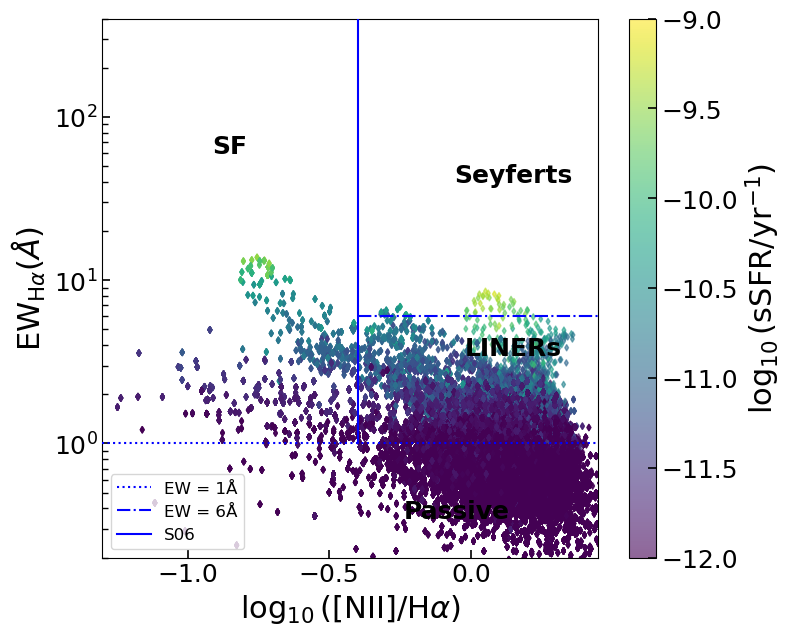

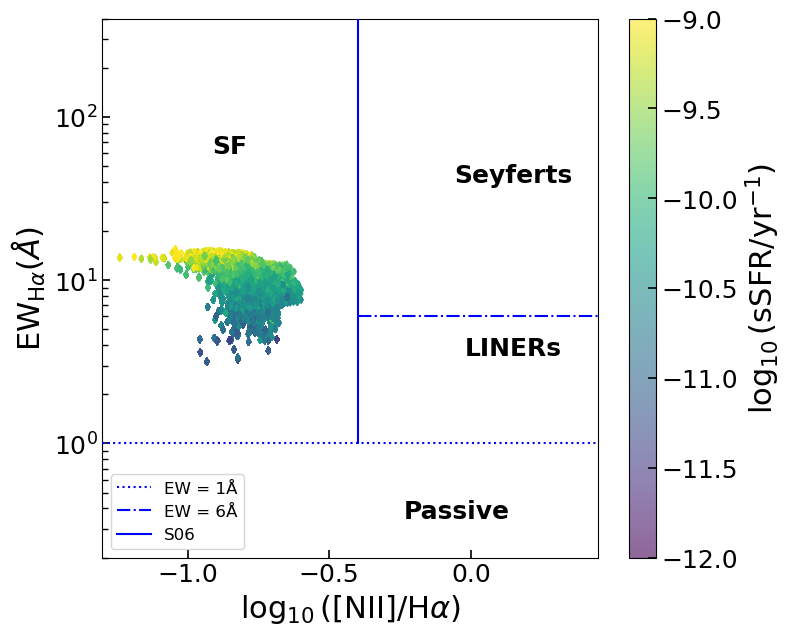

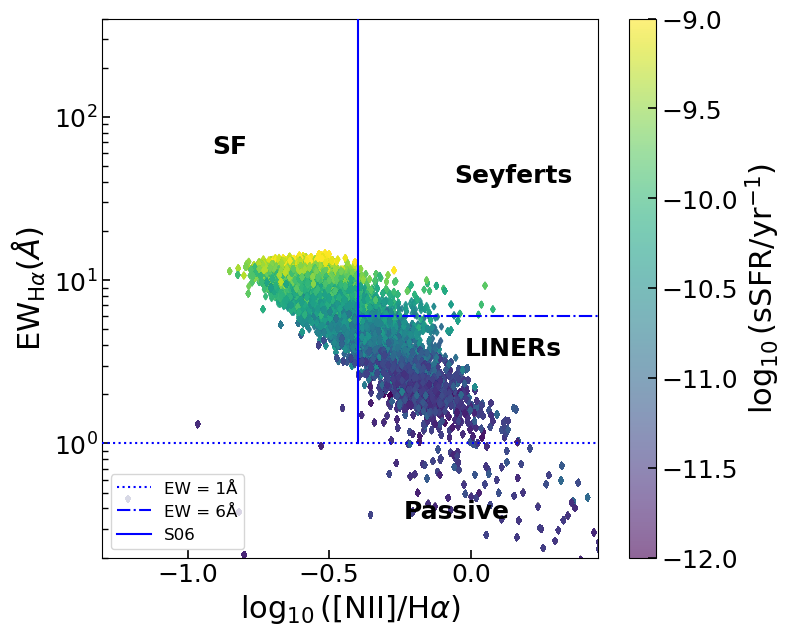

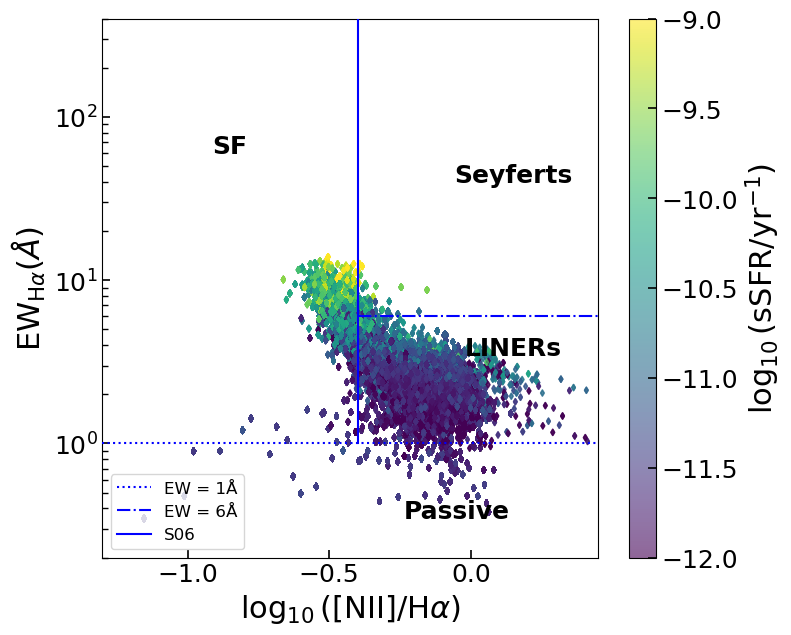

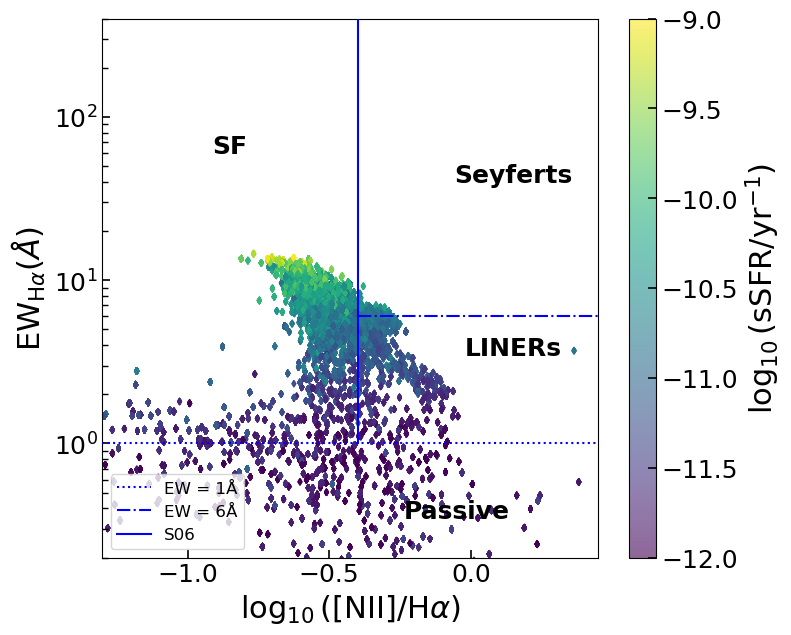

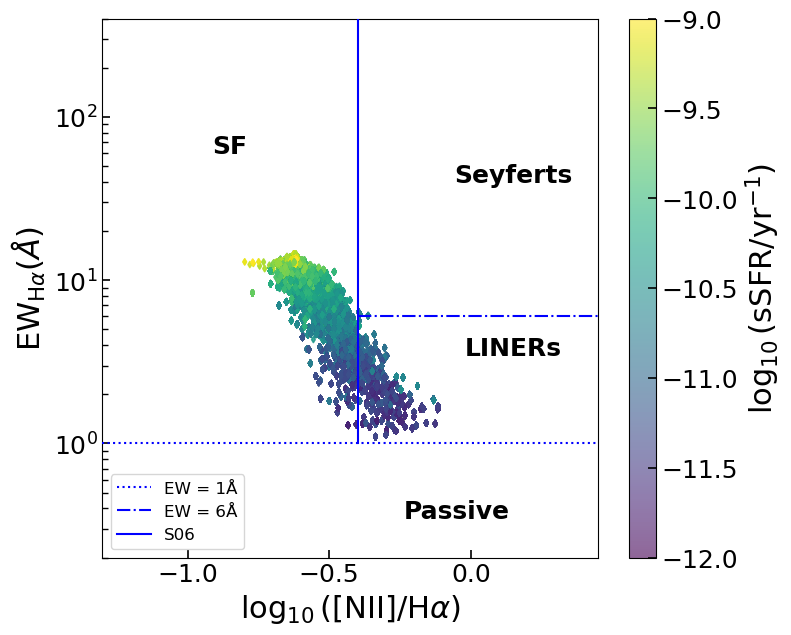

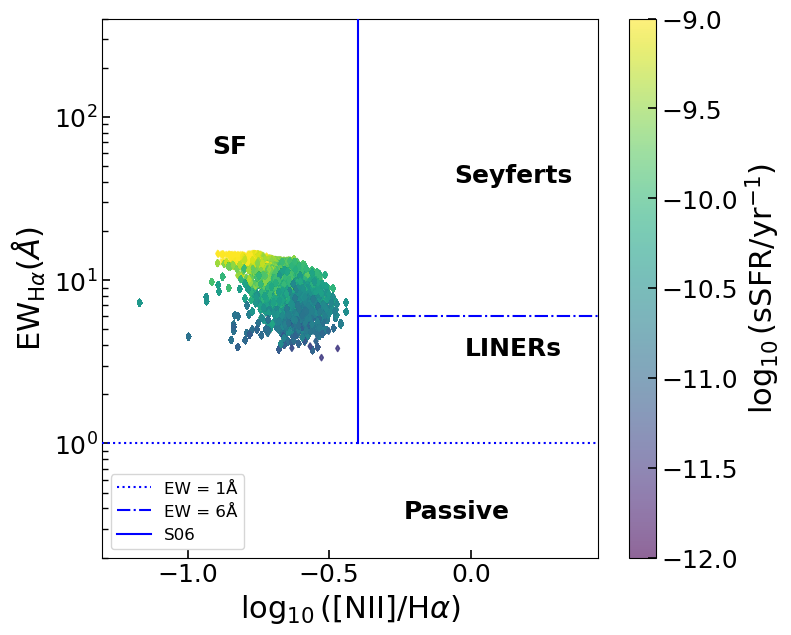

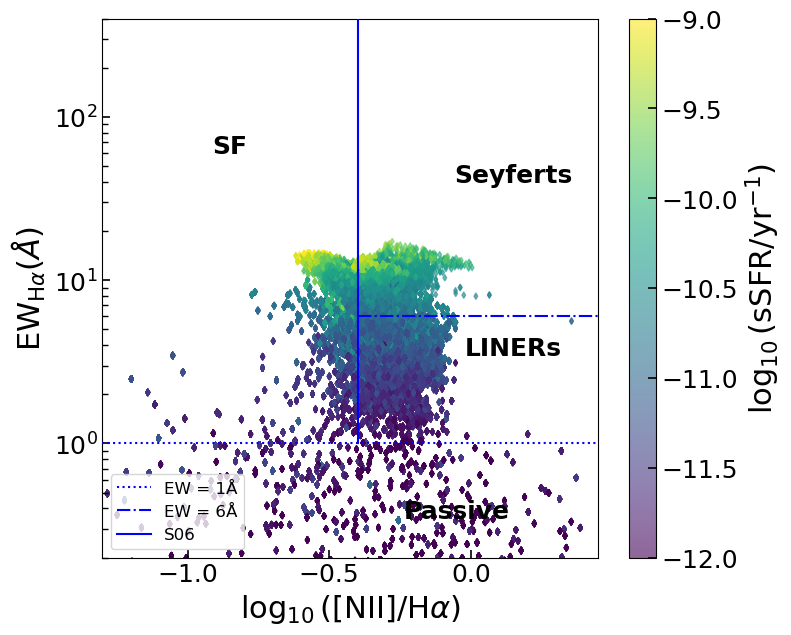

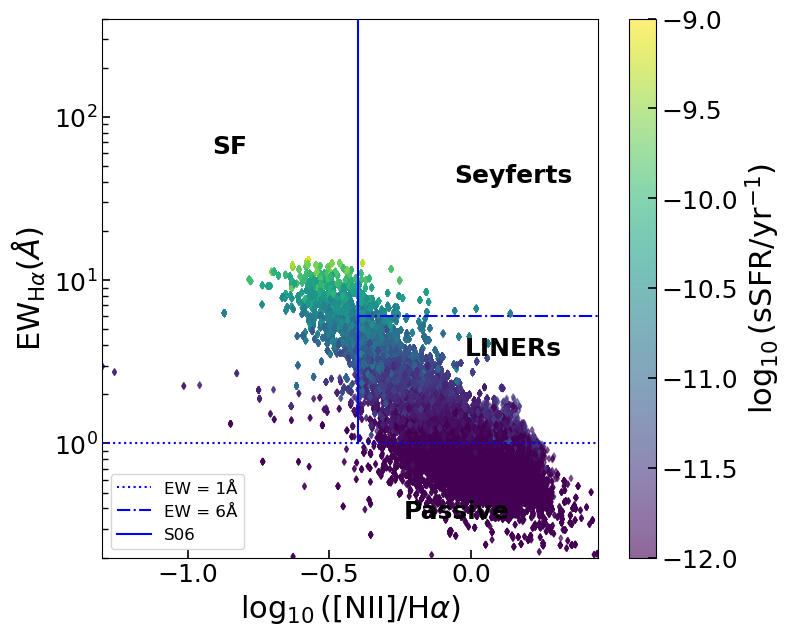

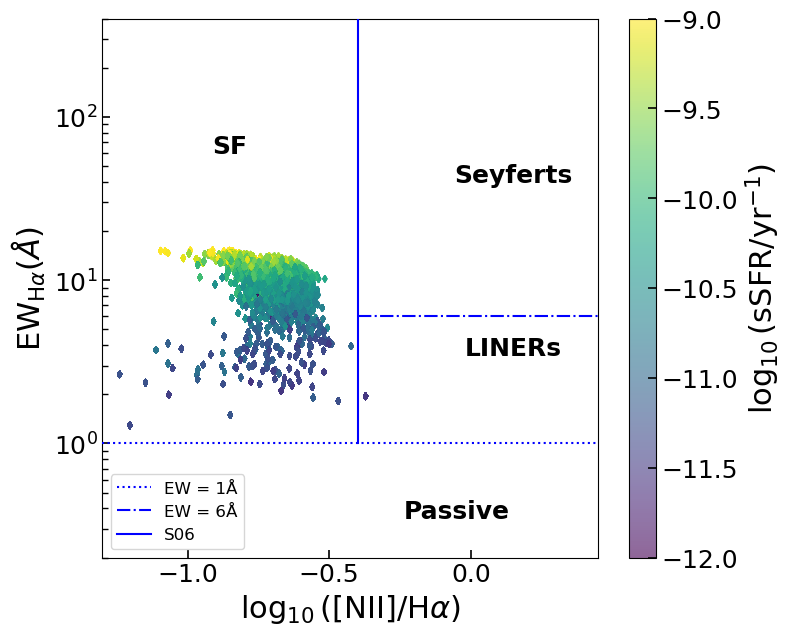

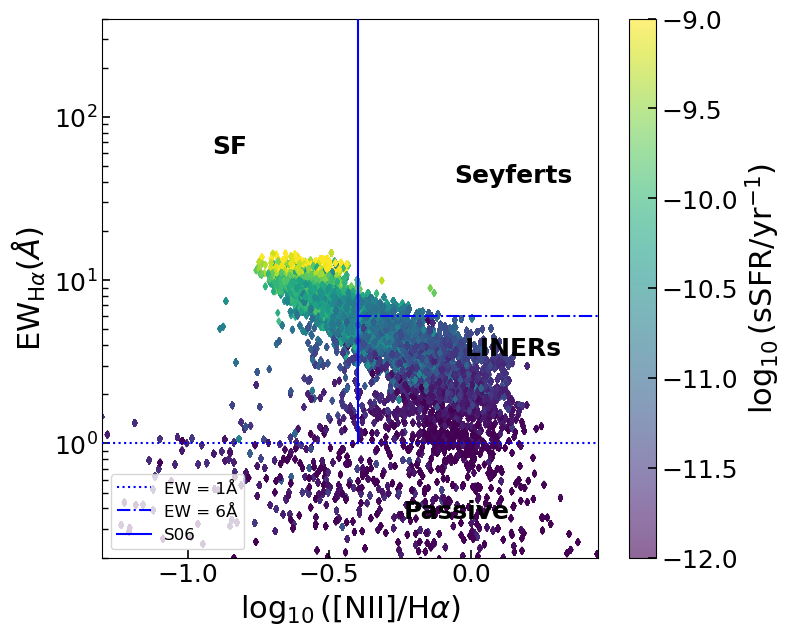

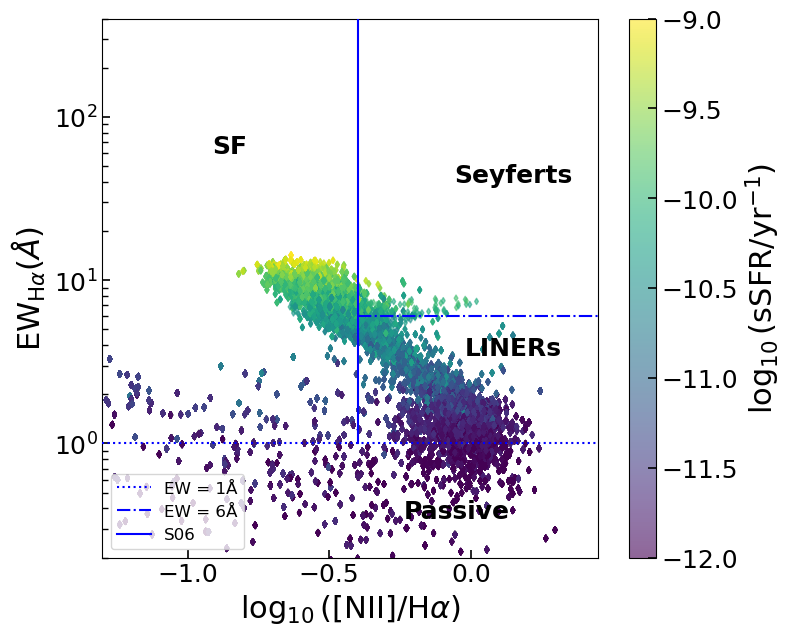

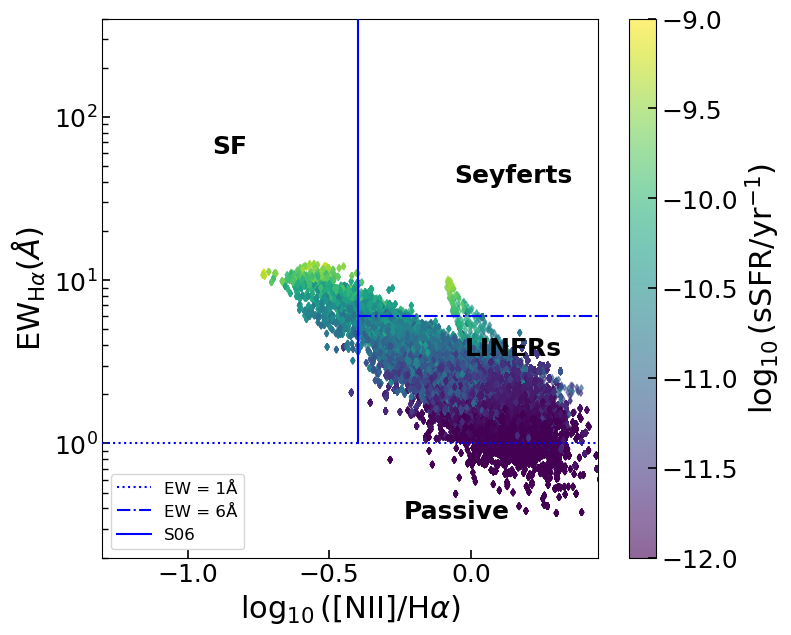

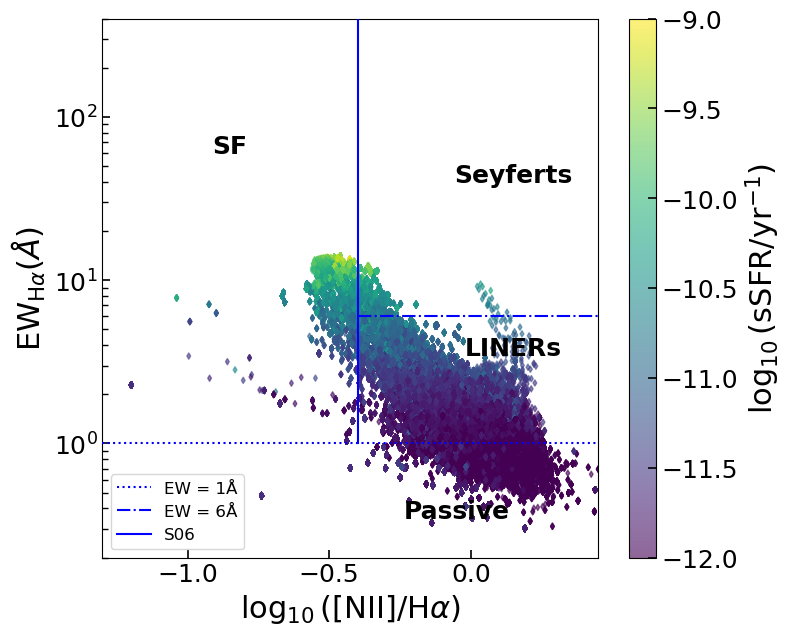

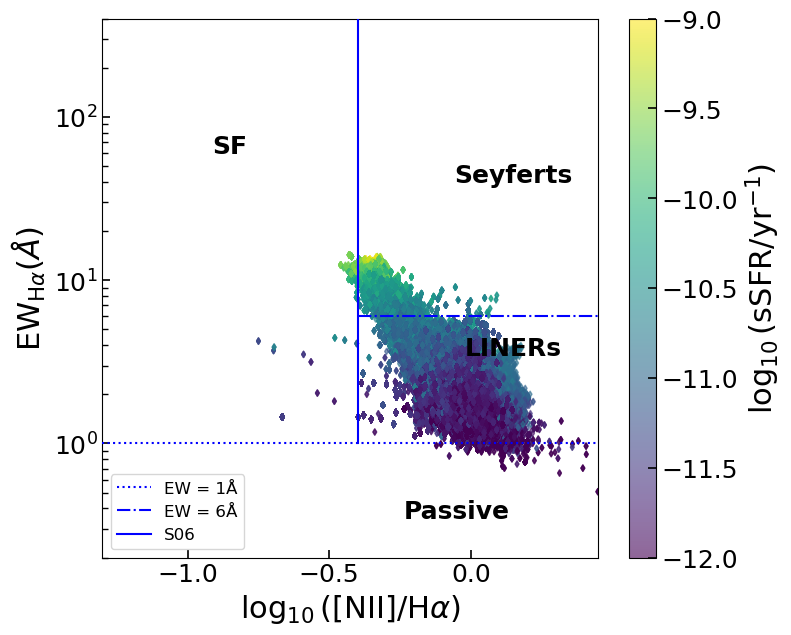

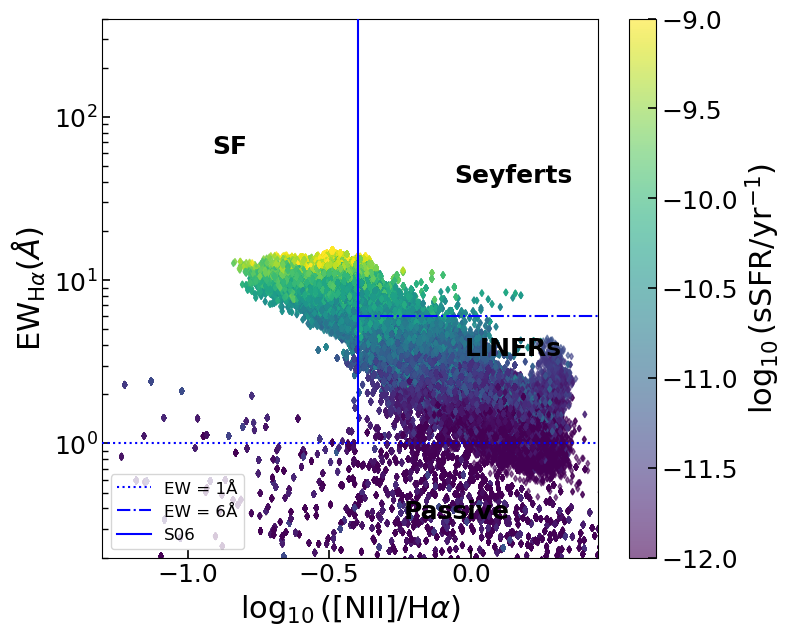

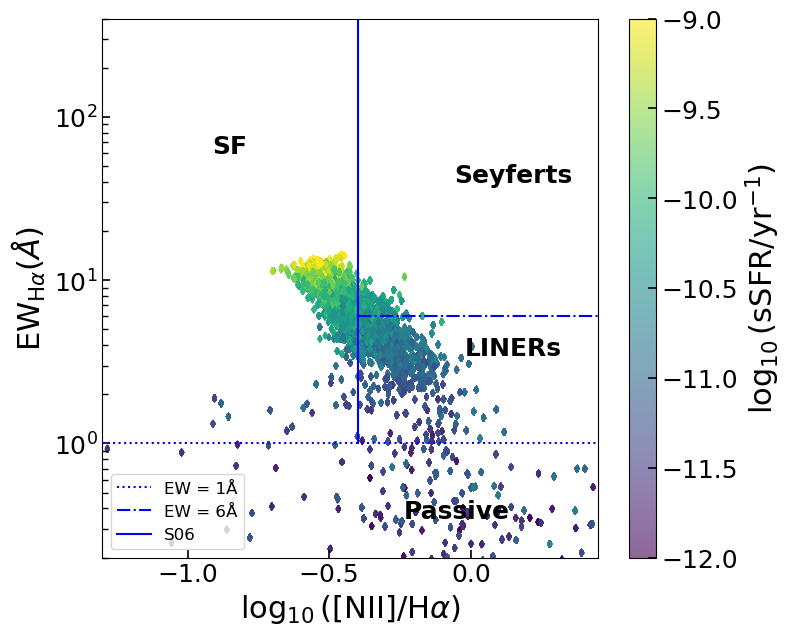

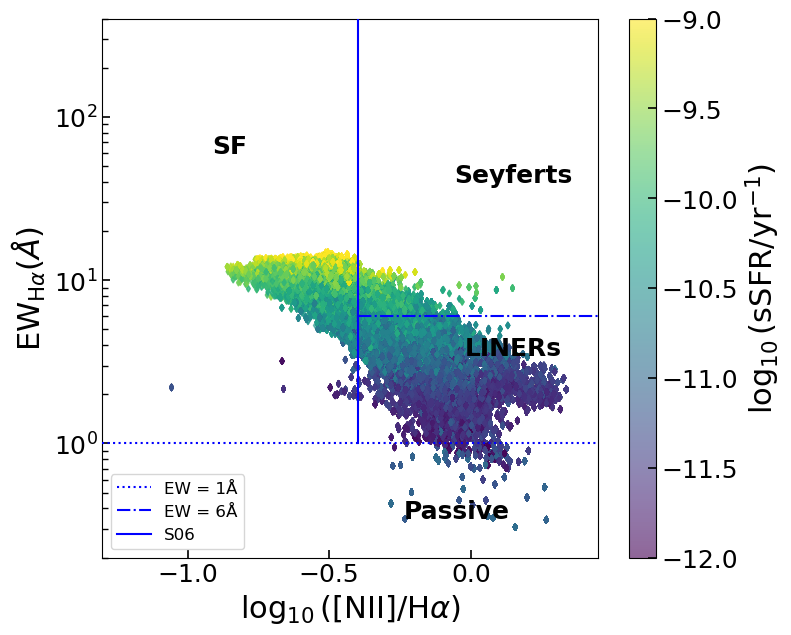

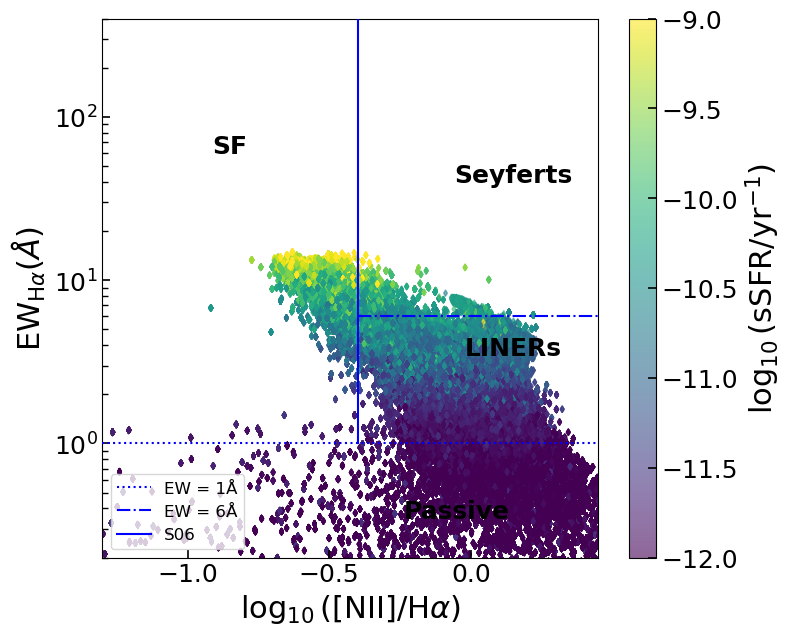

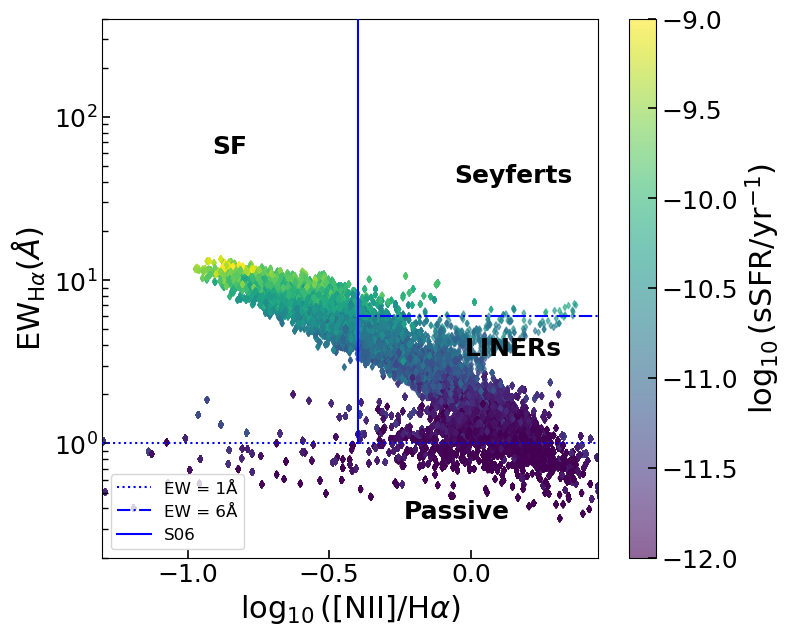

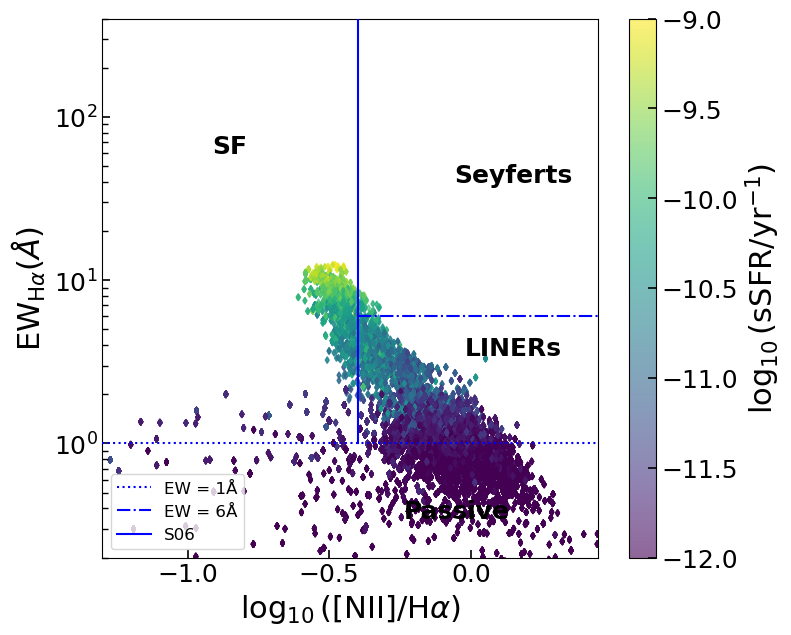

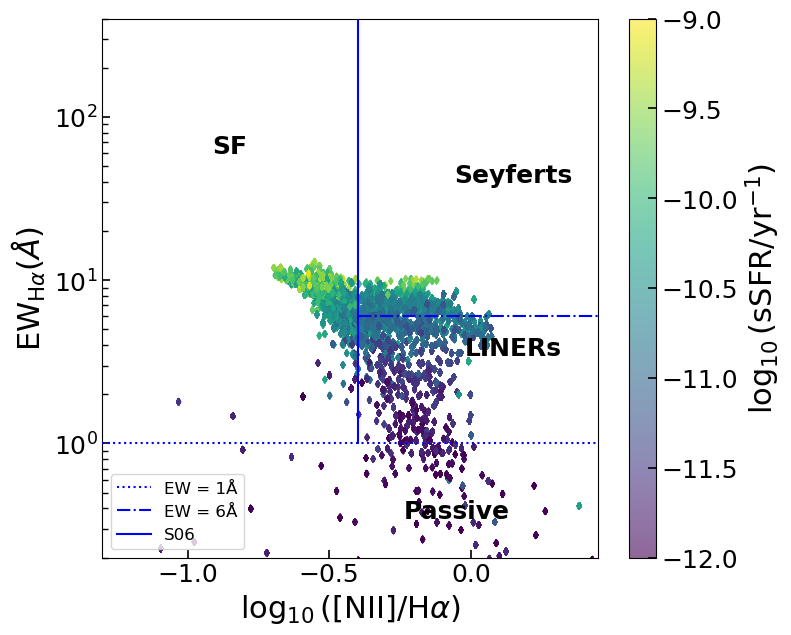

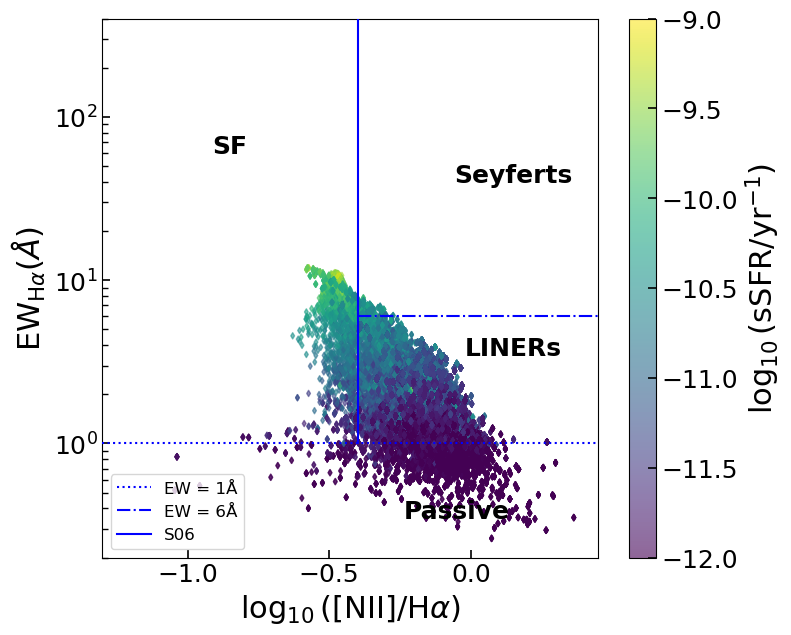

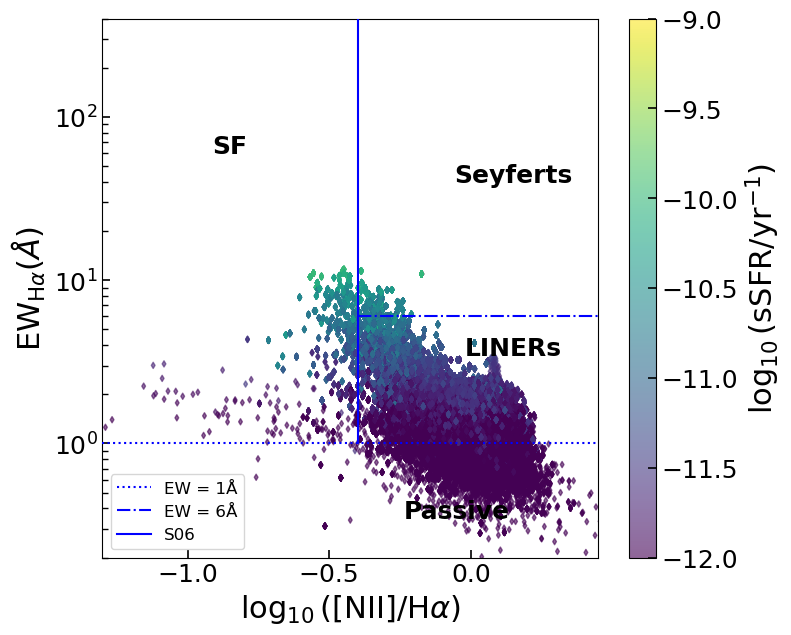

In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_MIN = 6.0


# Loop over all galaxies with nested current-folder mass/SFR+EW products ready
PROJECT_ROOT = Path.cwd()
RUN_DIR = PROJECT_ROOT / 'v3tk_v7.6.8'

def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None

def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False

def further_spatial_path(gal):
    base = RUN_DIR / gal
    found = first_existing(
        base / f'{gal}_spatial_binning_maps_further.fits',
        base / f'{gal}_spatial_binning_maps.fits',
        base / f'{gal}_SPATIAL_BINNING_maps_further.fits',
        base / f'{gal}_SPATIAL_BINNING_maps.fits',
    )
    if found is None:
        raise FileNotFoundError(f'No spatial product registered for {gal}')
    return found

def further_gas_path(gal):
    base = RUN_DIR / gal
    found = first_existing(
        base / f'{gal}_gas_bin_maps_further.fits',
        base / f'{gal}_gas_BIN_maps_further.fits',
        base / f'{gal}_gas_bin_maps.fits',
        base / f'{gal}_gas_BIN_maps.fits',
    )
    if found is None:
        raise FileNotFoundError(f'No gas product registered for {gal}')
    return found

def further_ew_path(gal, suffix=EW_FILE_SUFFIX):
    base = RUN_DIR / gal
    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(['_proxy_EW_maps_further.fits', '_proxy_EW_maps.fits', '_pseudo_EW_maps.fits'])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.extend([
            base / f'{gal}{suffix_item}',
            PROJECT_ROOT / f'{gal}{suffix_item}',
        ])
    found = first_existing(*candidates)
    if found is None:
        checked = '\n'.join(f'  - {path}' for path in candidates)
        raise FileNotFoundError(f'No EW product found for {gal}. Checked:\n{checked}')
    return found

def physics_ready_galaxies(require_ew=True):
    galaxies = []
    if not RUN_DIR.exists():
        return galaxies
    for base in sorted(p for p in RUN_DIR.iterdir() if p.is_dir()):
        gal = base.name
        try:
            spatial_path = further_spatial_path(gal)
            gas_path = further_gas_path(gal)
            has_required = (
                fits_has_hdus(spatial_path, ['LOGMASS_SURFACE_DENSITY'])
                and fits_has_hdus(gas_path, ['LOGSFR_SURFACE_DENSITY_HII', 'LOGSFR_SURFACE_DENSITY_SF'])
                
            )
            if require_ew:
                has_required = has_required and further_ew_path(gal, EW_FILE_SUFFIX).exists()
            if has_required:
                galaxies.append(gal)
        except FileNotFoundError:
            pass
    return galaxies

def old_paper_cells_ready(require_ew=True):
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0

def align_map_to_shape(data, target_shape, label='map', fill_value=np.nan, max_delta=2):
    target_shape = tuple(target_shape)
    arr = np.asarray(data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f'{label}: cannot align ndim {arr.ndim} to target shape {target_shape}')
    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f'{label}: shape {arr.shape} differs too much from target {target_shape}')
    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f'  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}')
    return aligned

galaxies = physics_ready_galaxies(require_ew=True)
if not galaxies:
    print('Skipped visualisation: nested *_further mass/SFR+EW products are not ready yet.')

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = further_spatial_path(gal)
    gas_path = further_gas_path(gal)
    ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY'].data
        ha_sigma_obs = h_gas['HA6562_SIGMA'].data
        ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
        if ha_sigma_corr is None:
            raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
        if ha_sigma_corr.shape != ha_sigma_obs.shape:
            raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
        sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
        ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
        sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
        ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
        
        # Load NII and Ha corrected fluxes for WHAN diagram
        ha_corr = h_gas['HA6562_FLUX_CORR'].data
        nii_corr = h_gas['NII6583_FLUX_CORR'].data
        

        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        if EW_HDU not in h_ew:
            raise KeyError(f"Missing {EW_HDU} in {ew_path}")
        ew_ha = h_ew[EW_HDU].data
    ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
    # Removed EW and velocity dispersion selections for HII spaxels
    # ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
    # ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
    # sigSFR = np.where(ew_mask, sigSFR, np.nan)
    # oh_map = np.where(ew_mask, oh_map, np.nan)
    return sigM, sigSFR, wcs, gas_header, binid_map, ew_ha, ha_corr, nii_corr

for gal in galaxies:
    sigM, sigSFR, wcs_full, gas_header, binid_map, ew_ha, ha_corr, nii_corr = load_maps(gal)
    
    # Calculate WHAN diagram components
    valid_whan = (
        np.isfinite(ew_ha) & (ew_ha > 0) & 
        np.isfinite(ha_corr) & (ha_corr > 0) & 
        np.isfinite(nii_corr) & (nii_corr > 0) & 
        np.isfinite(sigSFR) & np.isfinite(sigM)
    )
    
    ew_ha_valid = ew_ha[valid_whan]
    log_nii_ha = np.log10(nii_corr[valid_whan] / ha_corr[valid_whan])
    log_ssfr = sigSFR[valid_whan] - sigM[valid_whan]
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Increase tick label font sizes and tick length/width specifically for WHAN
    ax.tick_params(axis='both', which='major', labelsize=18, size=6, width=1.2, direction='in')
    ax.tick_params(axis='both', which='minor', size=4, width=1.0, direction='in')
    
    scatter = ax.scatter(
        log_nii_ha, 
        ew_ha_valid, 
        c=log_ssfr, 
        cmap='viridis',
        s=10, 
        alpha=0.6,
        marker='d',
        vmin=-12.0,
        vmax=-9.0
    )
    
    ax.set_yscale('log')
    ax.set_ylim(0.2, 400)
    ax.set_xlim(-1.3, 0.45)
    
    ax.set_xlabel(r'$\log_{10}([\mathrm{NII}]/\mathrm{H}\alpha)$', fontsize=22)
    ax.set_ylabel(r'$\mathrm{EW}_{\mathrm{H}\alpha} (\AA)$', fontsize=22)
    
    # Draw WHAN boundaries
    ax.axhline(1.0, linestyle=':', color='blue', label='EW = 1Å', zorder=10)
    ax.plot([-0.4, 0.45], [6.0, 6.0], linestyle='-.', color='blue', label='EW = 6Å', zorder=10)
    ax.plot([-0.4, -0.4], [1.0, 400], linestyle='-', color='blue', label='S06', zorder=10)
    
    ax.text(-0.85, 60, 'SF', fontsize=18, fontweight='bold', ha='center')
    ax.text(0.15, 40, 'Seyferts', fontsize=18, fontweight='bold', ha='center')
    ax.text(0.15, 3.5, 'LINERs', fontsize=18, fontweight='bold', ha='center')
    ax.text(-0.05, 0.35, 'Passive', fontsize=18, fontweight='bold', ha='center')
    
    cbar = fig.colorbar(scatter, ax=ax, pad=0.05)
    cbar.set_label(r'$\log_{10}(\mathrm{sSFR} / \mathrm{yr}^{-1})$', fontsize=22)
    cbar.ax.tick_params(labelsize=18)
    
    ax.legend(loc='lower left', fontsize=12)
    
    # fig.savefig(f'Moran_MAUVE/{gal}_WHAN_diagram.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Moran_MAUVE/{gal}_WHAN_diagram.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

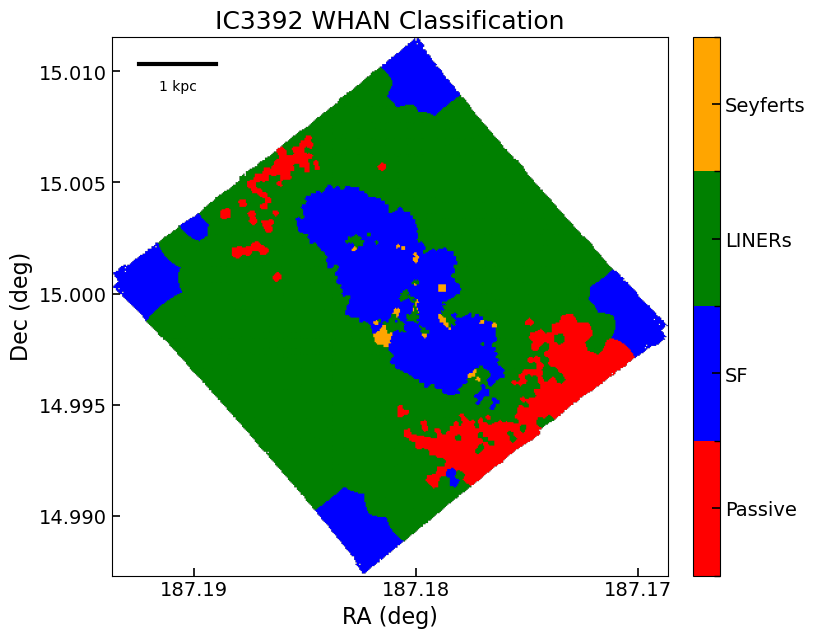

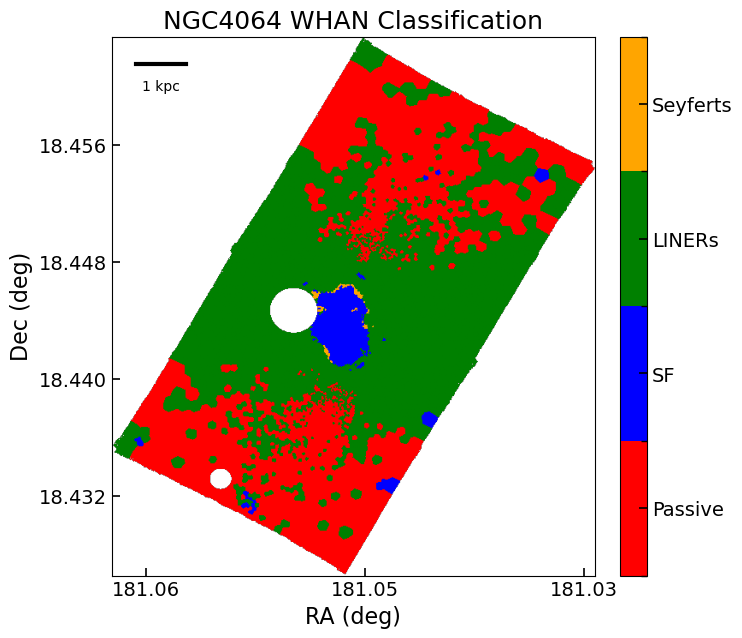

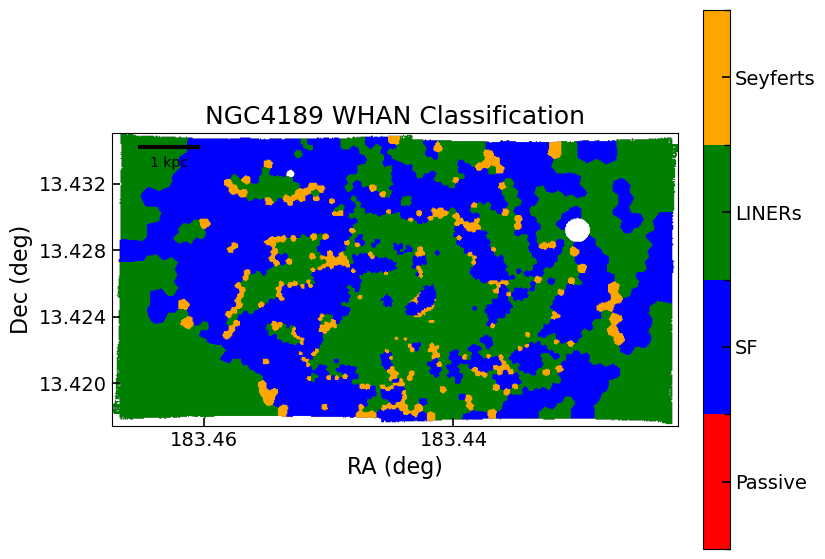

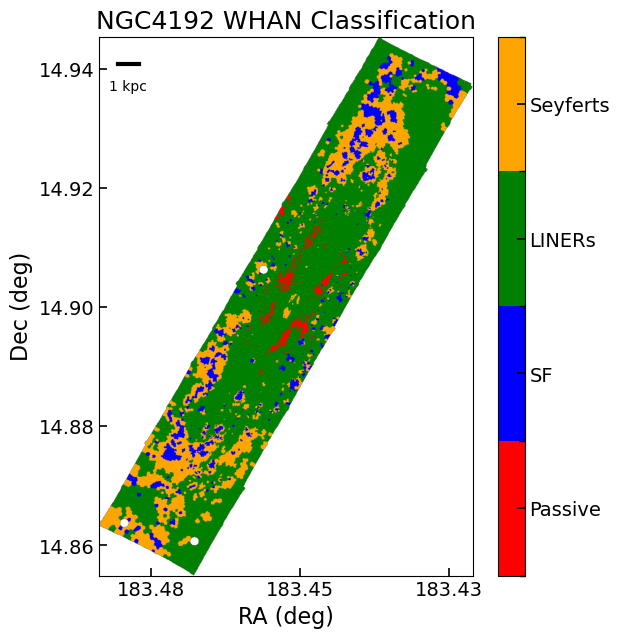

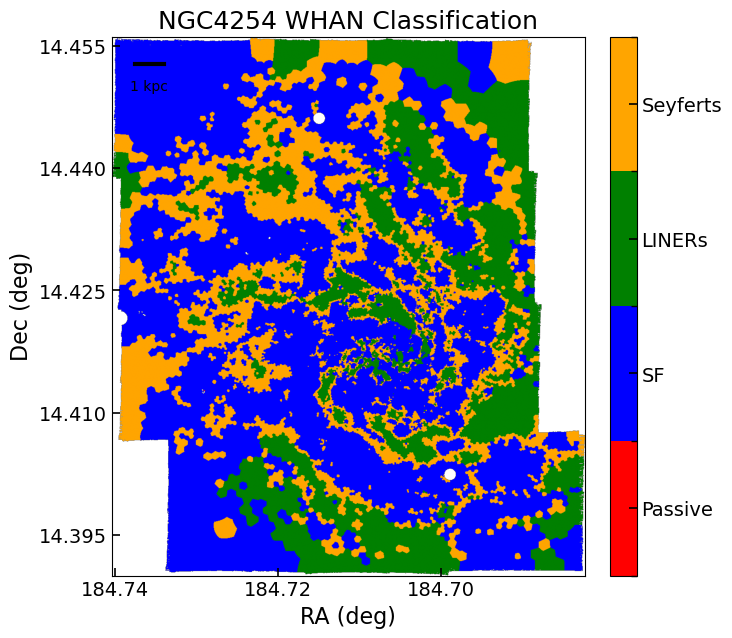

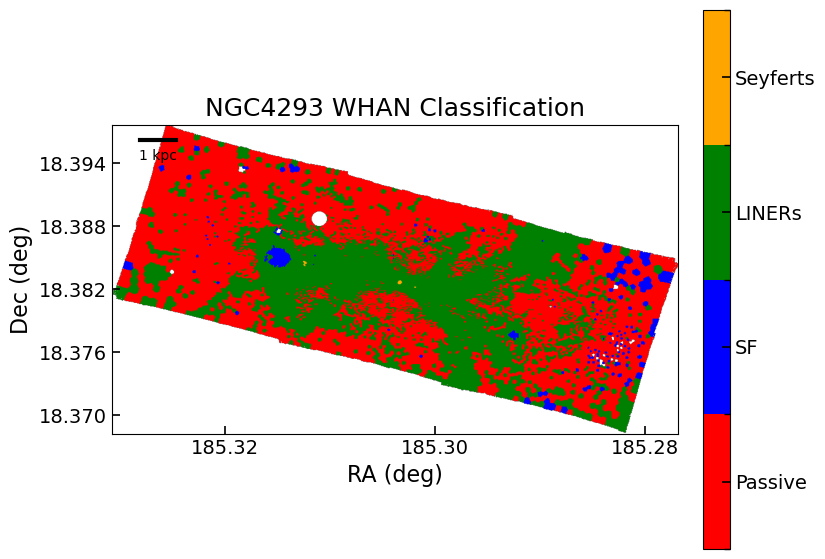

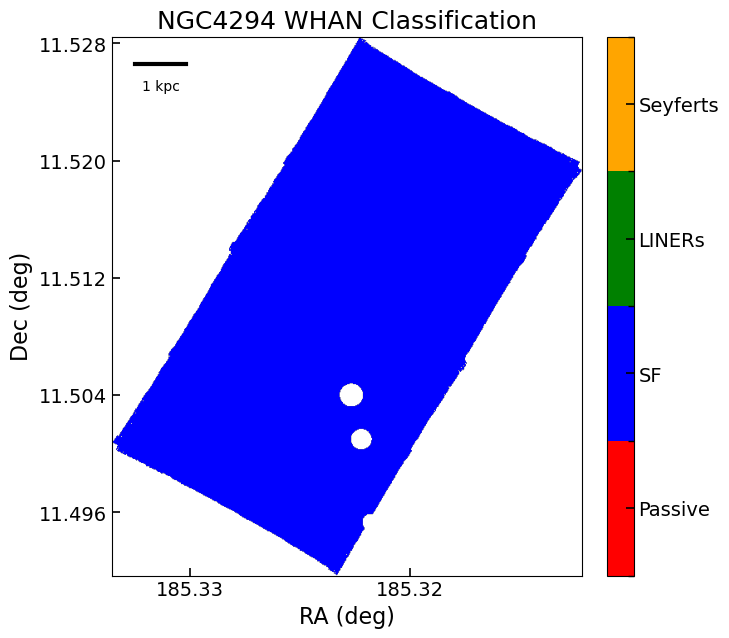

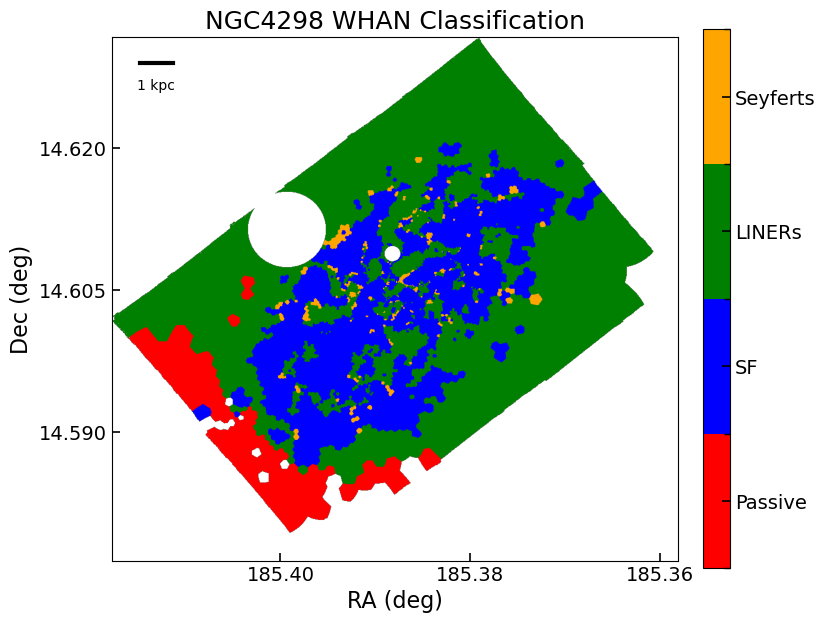

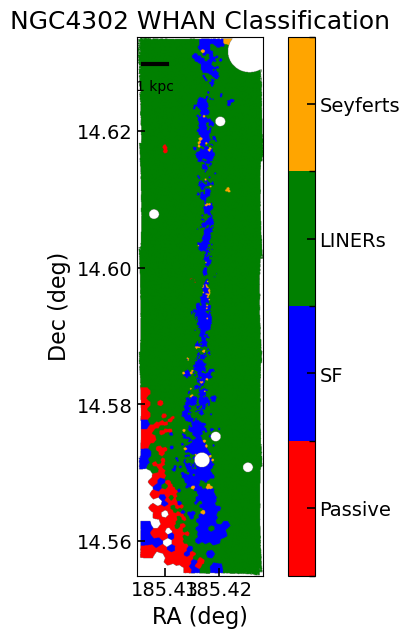

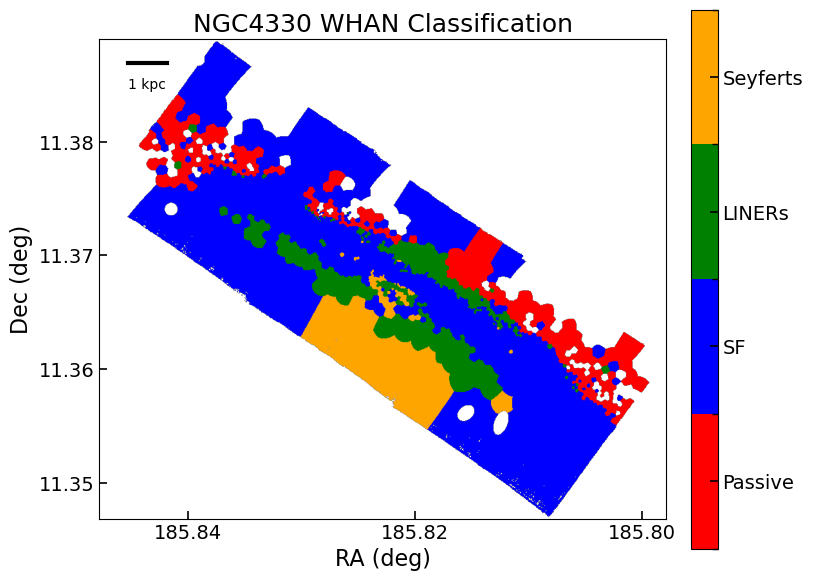

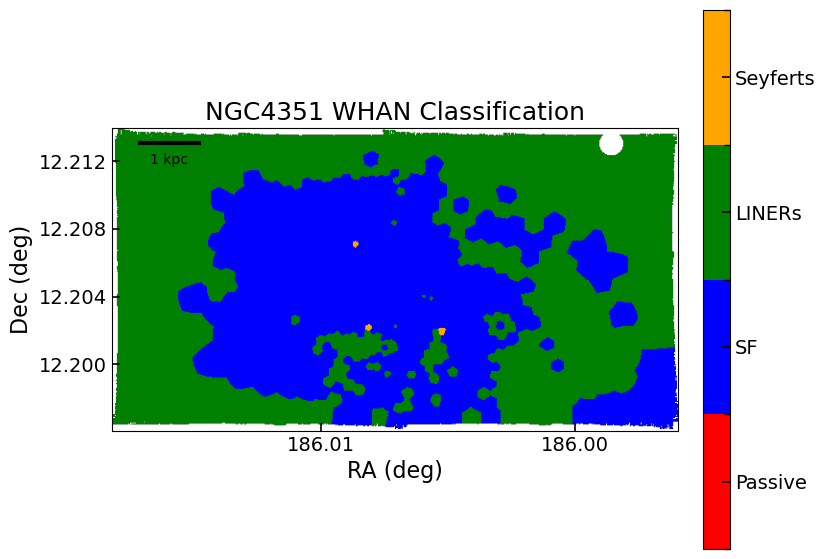

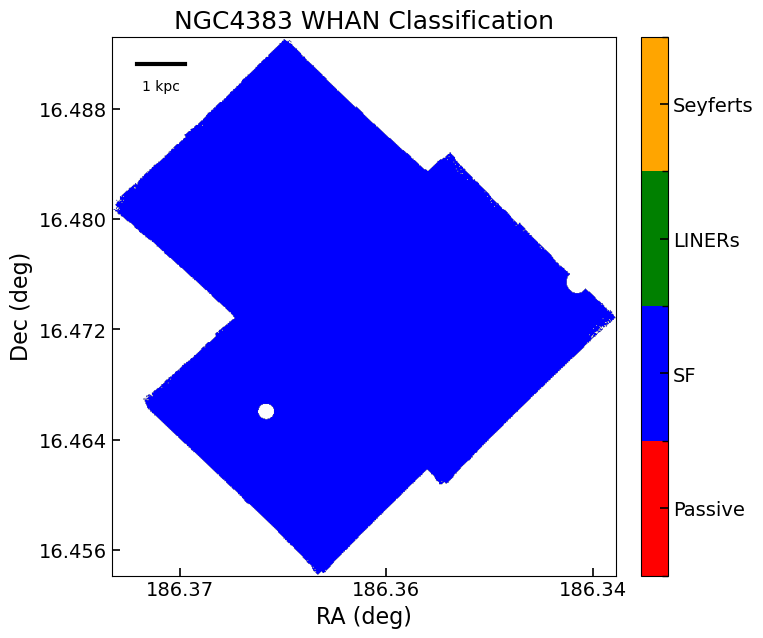

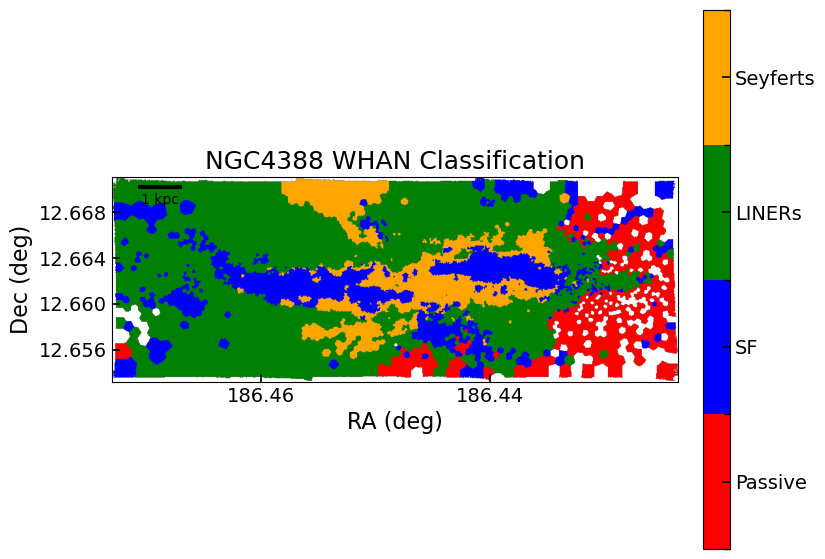

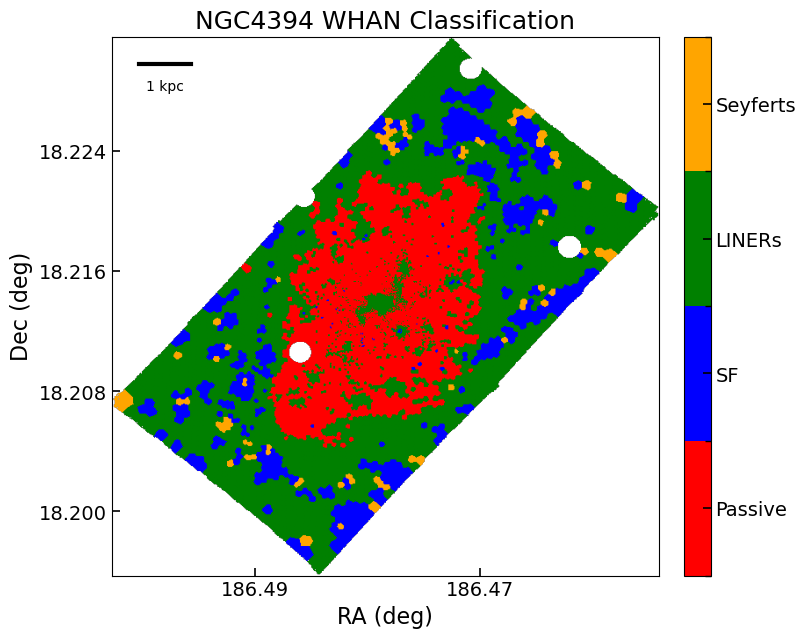

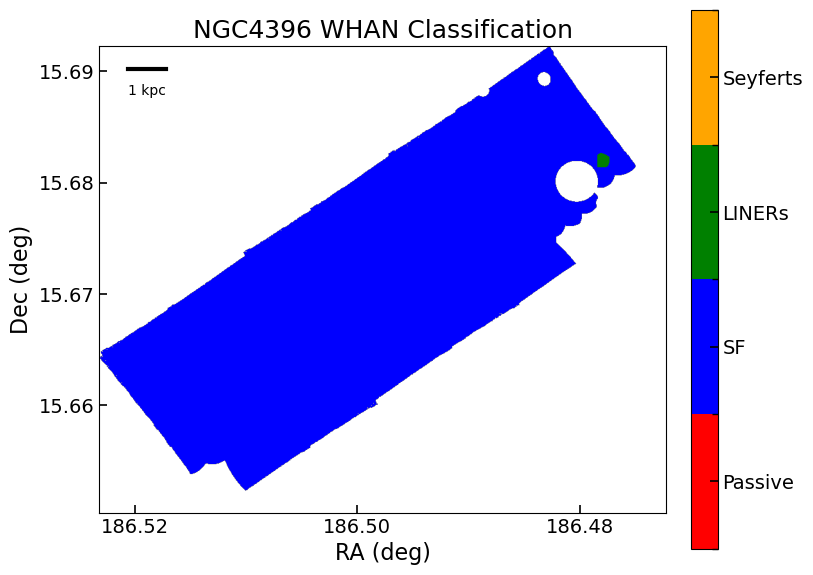

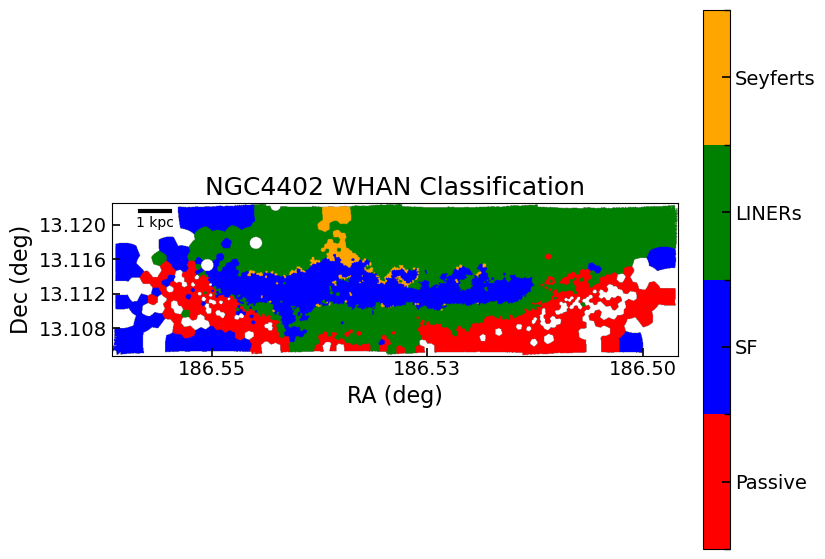

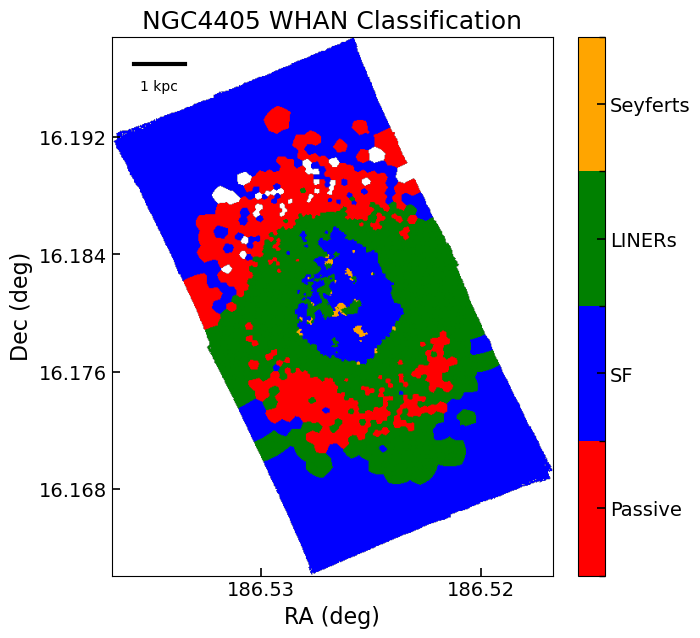

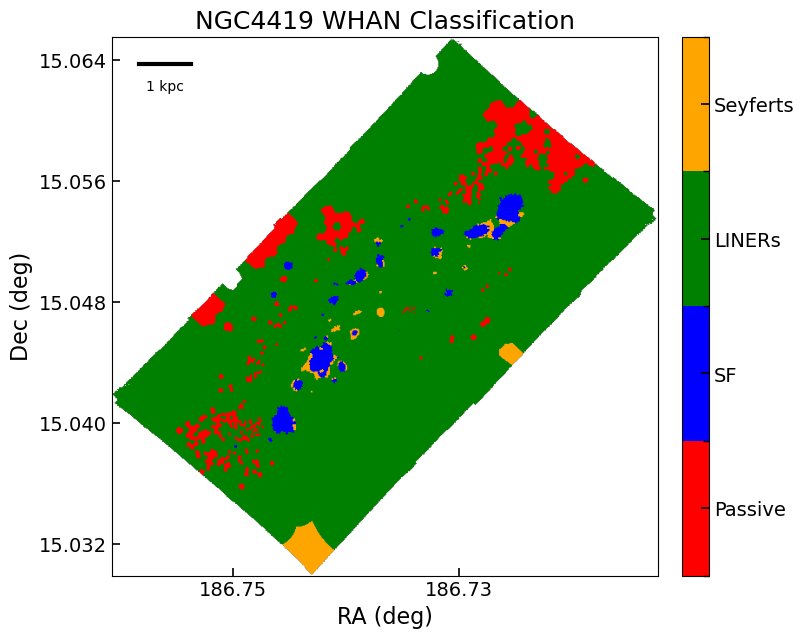

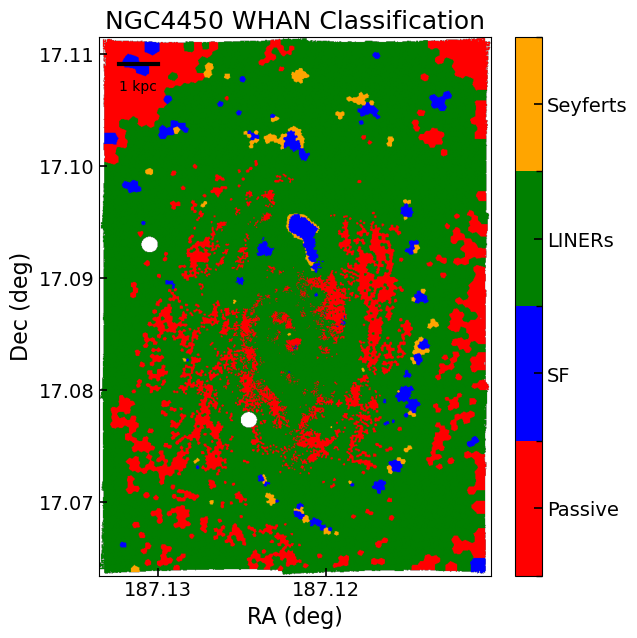

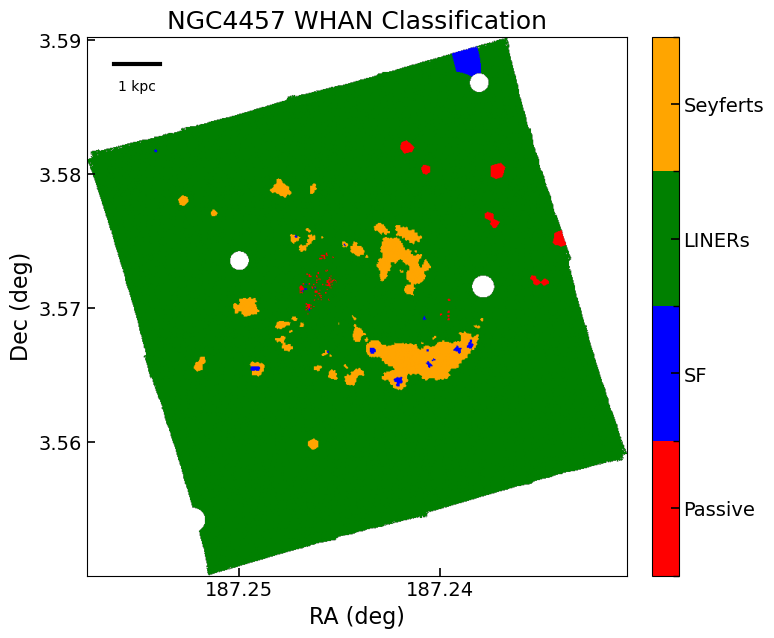

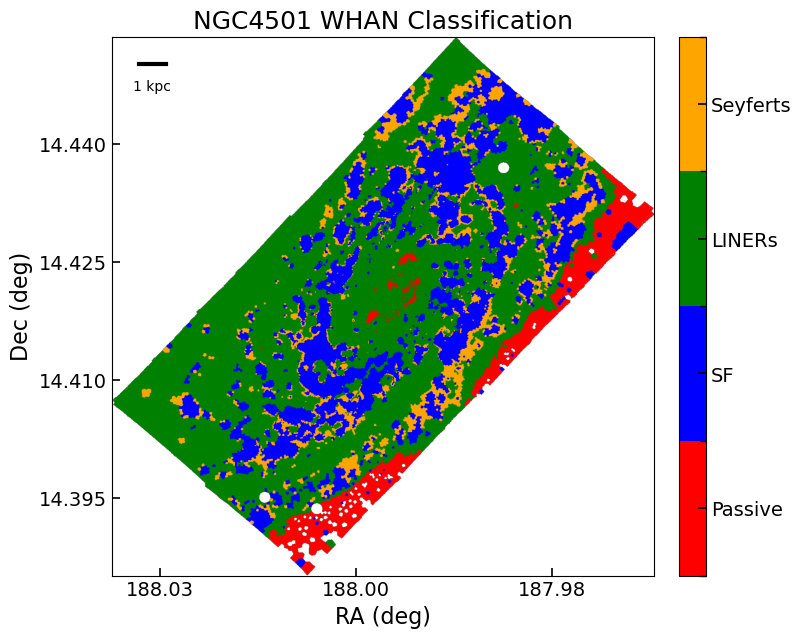

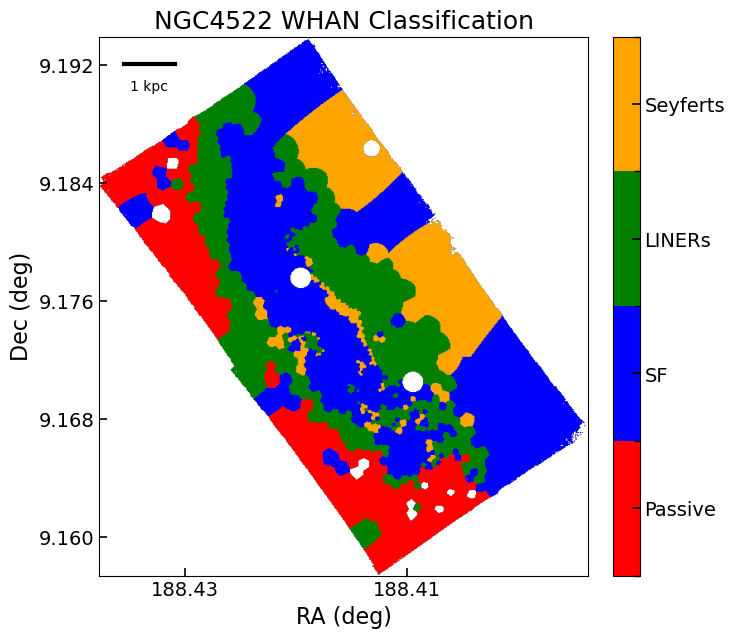

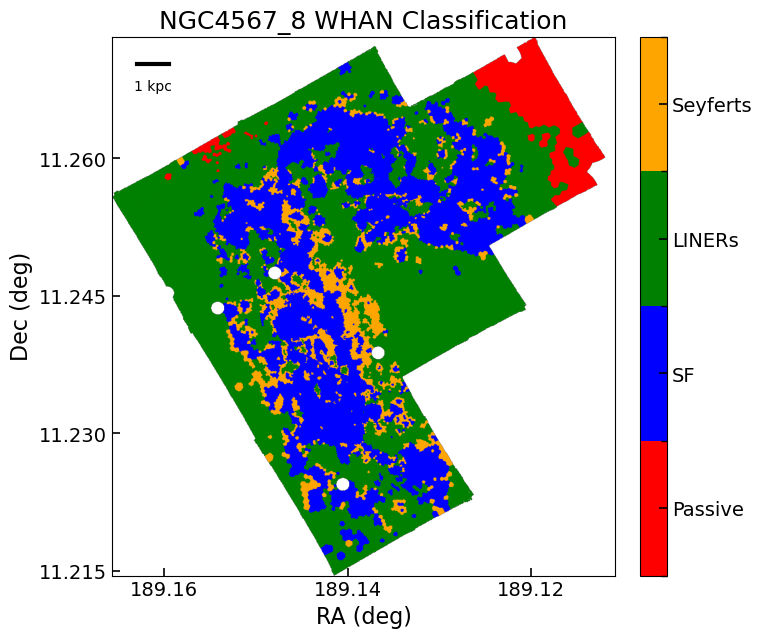

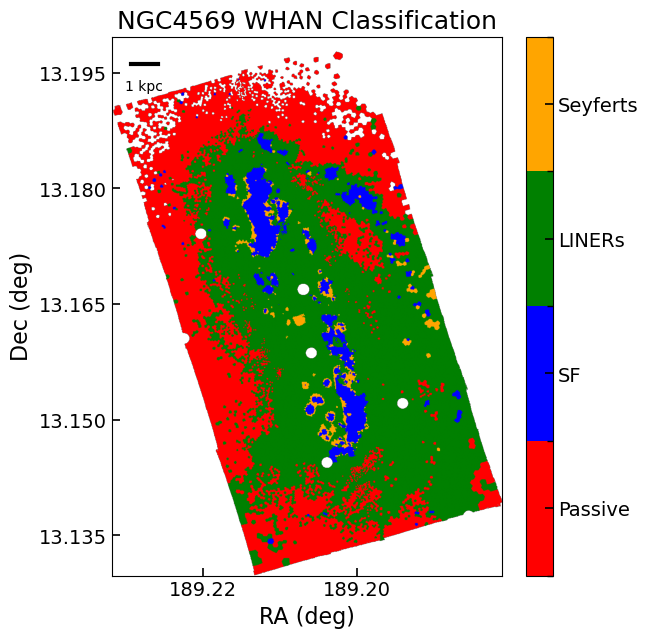

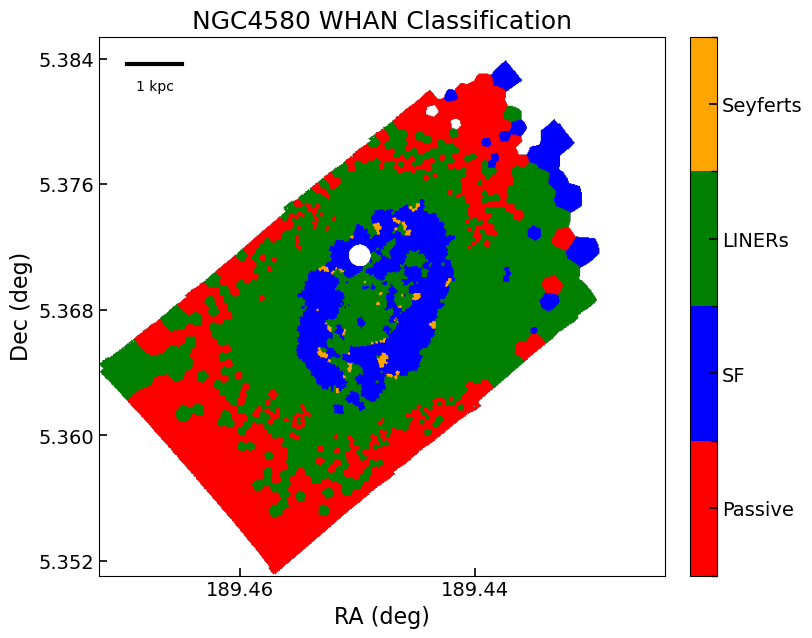

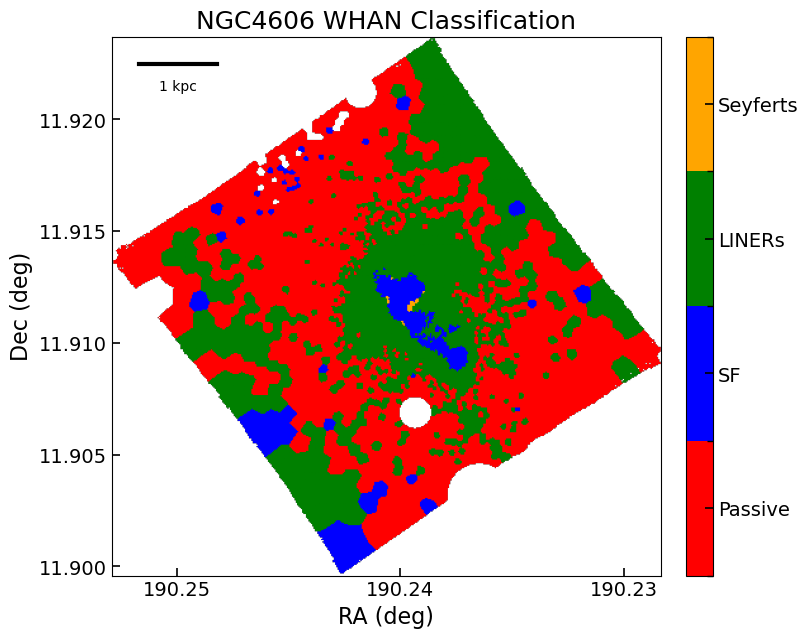

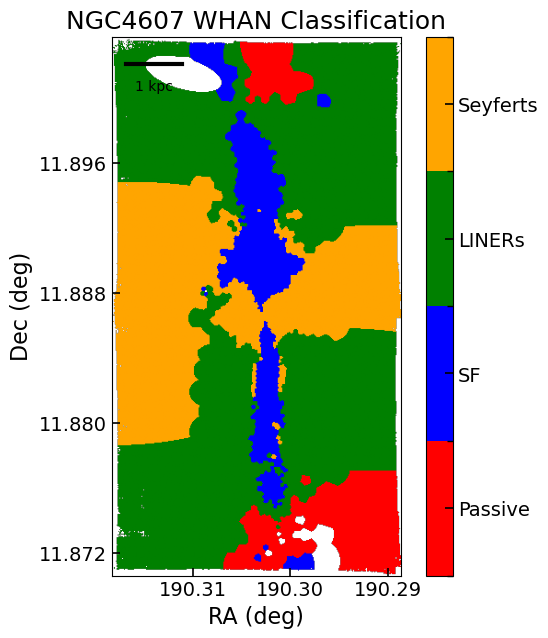

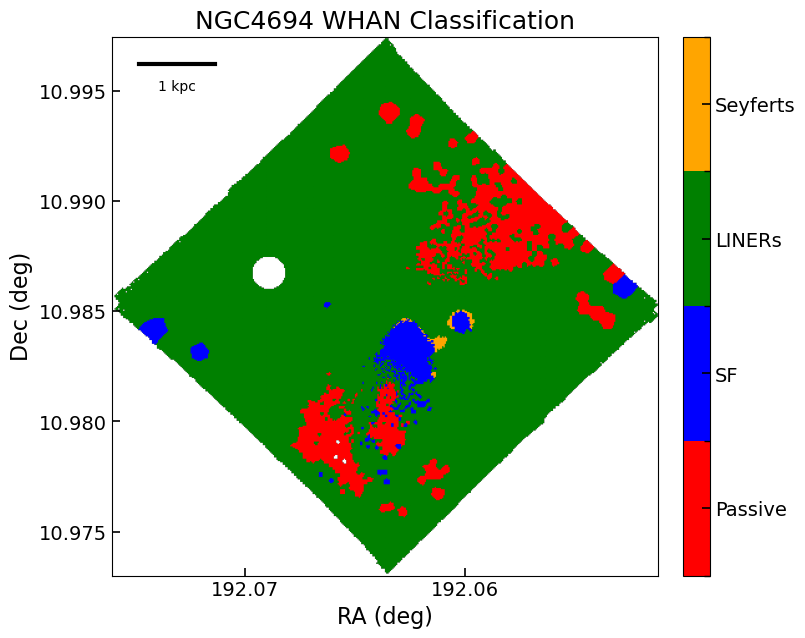

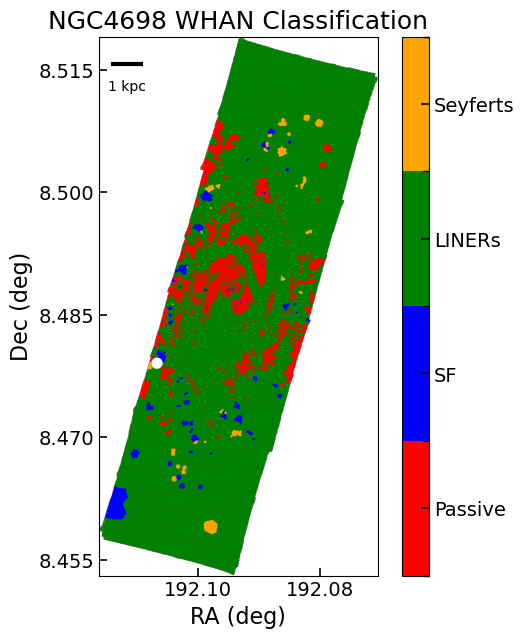

In [3]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

for gal in galaxies:
    sigM, sigSFR, wcs_full, gas_header, binid_map, ew_ha, ha_corr, nii_corr = load_maps(gal)
    
    # Calculate WHAN diagram components
    valid_whan = (
        np.isfinite(ew_ha) & (ew_ha > 0) & 
        np.isfinite(ha_corr) & (ha_corr > 0) & 
        np.isfinite(nii_corr) & (nii_corr > 0) & 
        np.isfinite(sigSFR) & np.isfinite(sigM)
    )
    
    log_nii_ha = np.full_like(ew_ha, np.nan)
    log_nii_ha[valid_whan] = np.log10(nii_corr[valid_whan] / ha_corr[valid_whan])
    
    # WHAN classification map
    whan_class = np.full(ew_ha.shape, np.nan)
    
    # Passive: -1, SF: 0, LINERs: 1, Seyferts: 2
    whan_class[valid_whan & (ew_ha < 1.0)] = -1
    whan_class[valid_whan & (log_nii_ha < -0.4) & (ew_ha >= 1.0)] = 0
    whan_class[valid_whan & (log_nii_ha >= -0.4) & (ew_ha >= 1.0) & (ew_ha < 6.0)] = 1
    whan_class[valid_whan & (log_nii_ha >= -0.4) & (ew_ha >= 6.0)] = 2
    
    # Setup coordinates
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]
    
    # Scale bar
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0
    
    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)
        
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Set up ListedColormap
    cmap_whan = mcolors.ListedColormap(['red', 'blue', 'green', 'orange'])
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm_whan = mcolors.BoundaryNorm(bounds, cmap_whan.N)
    
    im = ax.imshow(
        np.ma.masked_invalid(whan_class),
        origin="lower", cmap=cmap_whan, norm=norm_whan,
        extent=extent, aspect="equal"
    )
    
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    ax.set_xlabel("RA (deg)", fontsize=16)
    ax.set_ylabel("Dec (deg)", fontsize=16)
    
    add_scalebar(ax, scalebar_length_deg, label="1 kpc")
    
    # Custom colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[-1, 0, 1, 2])
    cbar.ax.set_yticklabels(['Passive', 'SF', 'LINERs', 'Seyferts'], fontsize=14)
    
    ax.set_title(f"{gal} WHAN Classification", fontsize=18)
    
    # fig.savefig(f'Moran_MAUVE/{gal}_WHAN_map.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Moran_MAUVE/{gal}_WHAN_map.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()